In [1]:
import torch
import torch.distributions as D
import gensn.distributions as G
import gensn
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam
from task_transfer.routines import mc_marginal_log_likelihood

seed = 42
torch.manual_seed(seed)
rng = np.random.default_rng(seed)

# Create observation dataset from ground truth joint distribution

In [2]:
# Pick 2d prior for visualization as of now
prior_dim = 2
conditional_dim = 3
mc_sample_size = (200,)
obs_batch_dim = 128
dataset_size = 10_000
train_size = 8_000
test_size = 2_000

In [3]:
# set true prior and conditional params
true_prior_mean = torch.rand(prior_dim)
true_prior_cov = torch.rand((prior_dim, prior_dim))
# true_prior_cov = true_prior_cov @ true_prior_cov.T + torch.finfo(true_prior_cov.dtype).eps * torch.eye(prior_dim)
true_prior_cov = torch.rand((prior_dim, prior_dim))
true_prior_cov = true_prior_cov @ true_prior_cov.T + torch.finfo(
    true_prior_cov.dtype
).eps * torch.eye(prior_dim)
true_prior_cov = -true_prior_cov * -torch.eye(prior_dim)
prior = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=true_prior_mean, covariance_matrix=true_prior_cov
)

In [4]:
likelihood_fn = torch.nn.Linear(prior_dim, conditional_dim)
likelihood_fn.weight.data = torch.rand(conditional_dim, prior_dim)
likelihood_fn.bias.data = torch.rand(conditional_dim)
conditional_cov = torch.rand((conditional_dim, conditional_dim))
conditional_cov = conditional_cov @ conditional_cov.T + torch.finfo(
    conditional_cov.dtype
).eps * torch.eye(conditional_dim)
conditional = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=likelihood_fn, covariance_matrix=conditional_cov
)
joint = G.Joint(prior=prior, conditional=conditional)

In [5]:
latent_samples, obs_samples = joint.sample((dataset_size,))
print(obs_samples.shape, latent_samples.shape)

torch.Size([10000, 3]) torch.Size([10000, 2])


In [6]:
# visualize the true prior
x, y = np.mgrid[-1.5:3:.01, -1.5:3:.01]
pos = np.dstack((x, y))
prior_pdf = prior(torch.tensor(pos)).exp()

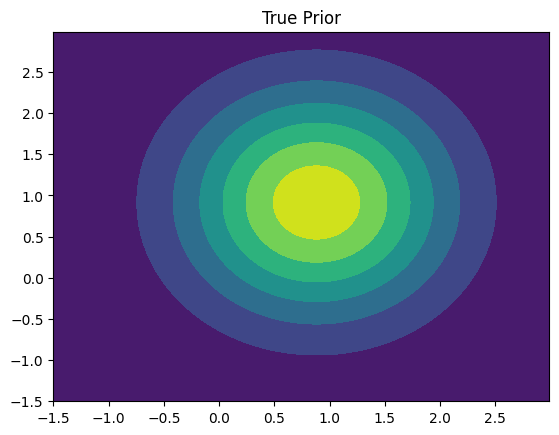

In [7]:
fig, ax = plt.subplots(dpi=100)
ax.contourf(x, y, prior_pdf)
ax.set_title("True Prior")
# ax.scatter(latent_samples[:, :, 0].flatten(), latent_samples[:,:, 1], s=1, c="r")
plt.show()

In [8]:
# create a pytorch dataloader with the observed samples
train_dataloader = DataLoader(
    TensorDataset(obs_samples[:train_size]),
    batch_size=obs_batch_dim,
    shuffle=True
)
test_dataloader = DataLoader(
    TensorDataset(obs_samples[train_size:]),
    batch_size=obs_batch_dim,
    shuffle=False
)

# Create a joint with a model prior and ground truth conditional

In [9]:
model_prior_mean = torch.nn.Parameter((torch.randn_like(true_prior_mean)))
model_prior_cov = gensn.parameters.Covariance(n_dims=prior_dim)
model_prior = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=model_prior_mean, covariance_matrix=model_prior_cov
)

model_likelihood_fn = likelihood_fn
model_conditional_cov = conditional_cov
model_conditional = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=likelihood_fn, covariance_matrix=conditional_cov
)
model_joint = G.Joint(prior=model_prior, conditional=conditional)

In [10]:
with torch.no_grad():
    true_losses = []
    for obs_batch in test_dataloader:
        obs = obs_batch[0]
        true_loss = -mc_marginal_log_likelihood(joint, obs, mc_sample_size, "mean")
        true_losses.append(true_loss)
    mean_true_loss = np.mean(true_losses)

In [11]:
mean_true_loss

3.483872

In [12]:
true_prior_mean, true_prior_cov

(tensor([0.8823, 0.9150]),
 tensor([[0.6957, 0.0000],
         [0.0000, 0.9028]]))

In [13]:
model_joint_prior_dist = model_joint.prior.distribution()
model_joint_prior_dist.mean, model_joint_prior_dist.covariance_matrix

(tensor([-0.5668,  0.5654], grad_fn=<ExpandBackward0>),
 tensor([[3.6030, 0.8851],
         [0.8851, 0.2686]], grad_fn=<ExpandBackward0>))

# Plot initialized model prior pdf against true prior pdf

In [14]:
learned_prior_pdf = model_joint.prior(torch.tensor(pos)).exp().detach().numpy()

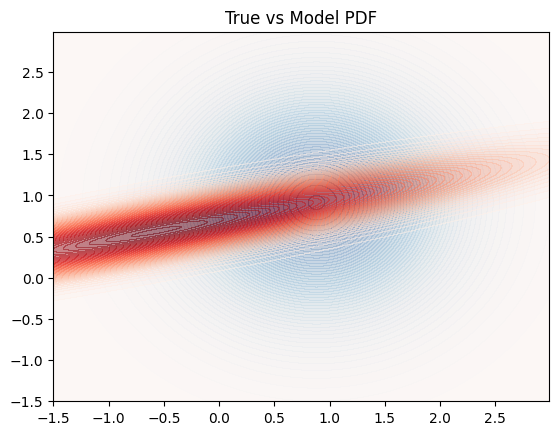

In [15]:
fig, ax = plt.subplots(dpi=100)
ax.contourf(x, y, prior_pdf, levels=50, cmap="Blues", alpha=0.5)
ax.contourf(x, y, learned_prior_pdf, levels=50, cmap="Reds", alpha=0.5)
ax.set_title("True vs Model PDF")
plt.show()

# Learn prior just via samples of observations via maximizing marginal likelihood

In [16]:
lr = 1e-3
optimizer = Adam(model_joint.prior.parameters(), lr=lr)
n_epochs = 100
train_losses = []
for epoch in range(n_epochs):
    total_loss = 0
    for obs_batch in train_dataloader:
        optimizer.zero_grad()
        obs = obs_batch[0]
        loss = -mc_marginal_log_likelihood(model_joint, obs, mc_sample_size, "mean")
        # loss = -joint.log_prob(obs_batch).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    mean_loss = total_loss / len(train_dataloader)
    print(f"Epoch {epoch} Loss: {mean_loss}")
    train_losses.append(mean_loss)

with torch.no_grad():
    true_losses = []
    for obs_batch in test_dataloader:
        obs = obs_batch[0]
        true_loss = -mc_marginal_log_likelihood(joint, obs, mc_sample_size, "mean")
        true_losses.append(true_loss)
    mean_true_loss = np.mean(true_losses)

        
    

Epoch 0 Loss: 3.9651803516206288
Epoch 1 Loss: 3.9232677732195174
Epoch 2 Loss: 3.898315391843281
Epoch 3 Loss: 3.859693103366428
Epoch 4 Loss: 3.830878257751465
Epoch 5 Loss: 3.7942924272446406
Epoch 6 Loss: 3.7634186290559315
Epoch 7 Loss: 3.7247184647454157
Epoch 8 Loss: 3.713125883586823
Epoch 9 Loss: 3.6796996215033153
Epoch 10 Loss: 3.660194393188234
Epoch 11 Loss: 3.6335234377119274
Epoch 12 Loss: 3.611897165813143
Epoch 13 Loss: 3.5941453093574163
Epoch 14 Loss: 3.5776482120392816
Epoch 15 Loss: 3.559840754857139
Epoch 16 Loss: 3.5564450612143865
Epoch 17 Loss: 3.5405832472301664
Epoch 18 Loss: 3.5298983180333696
Epoch 19 Loss: 3.5176654164753263
Epoch 20 Loss: 3.5109350227174305
Epoch 21 Loss: 3.5026233877454485
Epoch 22 Loss: 3.495344222538055
Epoch 23 Loss: 3.491680345838032
Epoch 24 Loss: 3.4902243689885215
Epoch 25 Loss: 3.48717266794235
Epoch 26 Loss: 3.4800880144512845
Epoch 27 Loss: 3.478552227928525
Epoch 28 Loss: 3.4734595730191185
Epoch 29 Loss: 3.4714675365932406
Ep

# Visualize learned prior

In [17]:
learned_prior_pdf = model_joint.prior(torch.tensor(pos)).exp().detach().numpy()

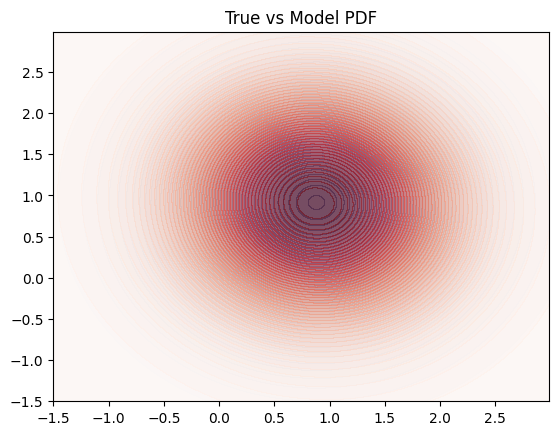

In [18]:
fig, ax = plt.subplots(dpi=100)
ax.contourf(x, y, prior_pdf, levels=50, cmap="Blues", alpha=0.5)
ax.contourf(x, y, learned_prior_pdf, levels=50, cmap="Reds", alpha=0.5)
ax.set_title("True vs Model PDF")
plt.show()